### Merging Inhibit time and runtime distribution to estimate true underlying distribution

logic
q(t) = P(IFCB looking at time t)
λobs​(t) = observed intensity at time t
λtrue​(t) true intensity at time t
λobs​(t)=q(t)λtrue​(t)

therefore 

λtrue​(t) = λobs(t)/q(t)
using the peicewise inhibition notebook to create a df of q(t) and applying this to df made from the util/class_taxonomicSort

In [ ]:

## This is really slow use the searchsorted version below.
# ## Define functions to compute inverse-probability weights for particle arrival times, given piecewise inhibition probabilities.

# import numpy as np
# import pandas as pd

# def get_inhibit_prob_at_times(times, inhibition_windows):
#     """
#     times: array-like observed particle arrival times
#     inhibition_windows: list of dicts, each with:
#         {
#             "t_start": float,
#             "t_end": float,
#             "p_inhibit": float
#         }

#     Returns p_inhibit(t) for each particle time.
#     """

#     times = np.asarray(times)
#     p = np.zeros_like(times, dtype=float)

#     for window in inhibition_windows:
#         mask = (
#             (times >= window["t_start"]) &
#             (times < window["t_end"])
#         )
#         p[mask] = window["p_inhib"]

#     return p


# def inverse_probability_weights(times, inhibition_windows, min_capture_prob=0.05):
#     """
#     Convert observed particle times into inverse-probability weights.
#     """

#     p_inhibit = get_inhibit_prob_at_times(times, inhibition_windows)

#     p_capture = 1 - p_inhibit

#     # avoid infinite weights if p_capture is near zero
#     p_capture = np.clip(p_capture, min_capture_prob, 1.0)

#     weights = 1 / p_capture

#     return pd.DataFrame({
#         "arrival_time": times,
#         "p_inhibit": p_inhibit,
#         "p_capture": p_capture,
#         "weight": weights
#     })



In [56]:
### Compiling RunTimes from directory of CSV files
## may also want to do this later with parquets could make it more intesting but to start keep it simple stupud

from pathlib import Path
import pandas as pd
import numpy as np

def compile_runtimes(directory):
    """
    Compile all values from the 'RunTime' column across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    runtimes : np.ndarray
        Array of all runtime values.

    n_files : int
        Number of CSV files that contained a 'RunTime' column.
    """
    runtimes = []
    n_files = 0

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)

        if "RunTime" in df.columns:
            runtimes.extend(df["RunTime"].dropna())
            n_files += 1

    return np.array(runtimes), n_files

In [74]:
## Get runtimes 
runtime_array, n_runs = compile_runtimes("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/nauset/merged_filtered/")

print(len(runtime_array))
print(runtime_array[:10])
print(f"Number of files processed: {n_runs}")

631071
[16.03380859 16.25113498 16.36419705 16.49421658 16.63845486 16.75815755
 16.91310764 17.00261936 17.12066406 17.24946398]
Number of files processed: 92


In [73]:
## get the piecewise inhibition probabilities from the previously computed dataframe
pw_df = pd.read_csv("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/nauset_pw_df.csv")
print(pw_df.head())


    t_start     t_end  active  inhib  p_inhib
0  0.000000  0.000004      92      0  0.00000
1  0.000004  0.000020      92      1  0.01087
2  0.000020  0.000033      92      1  0.01087
3  0.000033  0.000048      92      1  0.01087
4  0.000048  0.000056      92      0  0.00000


In [48]:
weighted_df = inverse_probability_weights(runtime_array, pw_df.to_dict(orient="records"))

KeyboardInterrupt: 

In [13]:
print(weighted_df.head())


   arrival_time  p_inhibit  p_capture    weight
0      2.369905   0.019608   0.980392  1.020000
1      3.814644   0.058824   0.941176  1.062500
2     10.368778   0.039216   0.960784  1.040816
3     11.894549   0.235294   0.764706  1.307692
4     12.198355   0.235294   0.764706  1.307692


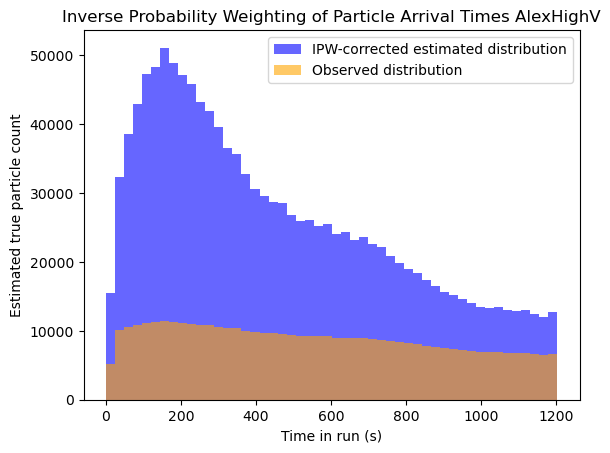

In [ ]:
# import matplotlib.pyplot as plt
# plt.hist(
#     weighted_df["arrival_time"],
#     bins=50,
#     weights=weighted_df["weight"],
#     alpha=0.6,
#     color='blue',
#     label="IPW-corrected estimated distribution"
# )
# plt.hist(
#     weighted_df["arrival_time"],
#     bins=50,
#     alpha=0.6,
#     color='orange',
#     label="Observed distribution"
# )
# plt.xlabel("Time in run (s)")
# plt.ylabel("Estimated true particle count")
# plt.title("Inverse Probability Weighting of Particle Arrival Times AlexHighV")
# plt.legend()
# plt.show()

## This forloop is pretty slow and this is a relatively small df what if i try a different way that chat suggested how much time do i save

In [71]:
import numpy as np

def compute_ipw_weights(runtimes, inhibit_df, min_capture_prob=0.05):
    """
    Compute inverse probability weights for a list of particle runtimes.

    Parameters
    ----------
    runtimes : array-like
        Particle arrival times.

    inhibit_df : DataFrame
        Must contain columns:
            - t_start
            - t_end
            - p_inhib

    Returns
    -------
    weights : np.ndarray
        Inverse probability weights for each runtime.
    """

    inhibit_df = inhibit_df.sort_values("t_start")

    t_start = inhibit_df["t_start"].to_numpy()
    t_end = inhibit_df["t_end"].to_numpy()
    p_inhibit = inhibit_df["p_inhib"].to_numpy()

    runtimes = np.asarray(runtimes)

    idx = np.searchsorted(t_start, runtimes, side="right") - 1

    p = np.zeros(len(runtimes))

    valid = (
        (idx >= 0) &
        (idx < len(t_start)) &
        (runtimes < t_end[idx])
    )

    p[valid] = p_inhibit[idx[valid]]

    p_capture = np.clip(1 - p, min_capture_prob, 1)

    weights = 1 / p_capture

    return weights

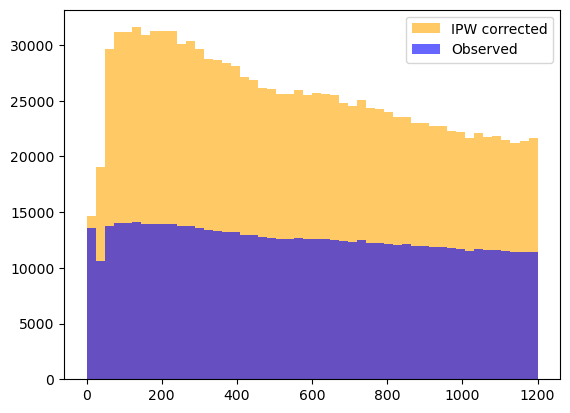

In [75]:
weights = compute_ipw_weights(runtime_array, pw_df, min_capture_prob=0.01)


plt.hist(runtime_array,
         bins=50,
         weights=weights,
         #density=True,
         color='orange',
         alpha=0.6,
         label="IPW corrected")
plt.hist(runtime_array, 
         bins=50, 
         alpha=0.6,
         #density=True,
         color='blue',
         label="Observed")

plt.legend()

### That seems to work and is pretty simple and alot faster i wonder if I can do it with the functional group part ill save the weights as an array and import in other notebook

In [85]:
np.save("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/nauset_filtered_weights.npy", weights)

### What I realy care about is how does this effect concentration estimates so i want to compare this weighted distrib that represents the true distribution of particles in the sample with the sampled concentration estimates created from the IFCB


In [76]:

totweight = np.sum(weights)
tot_observed = len(runtime_array)
print(f"Total weight: {totweight}, Total observed: {tot_observed}")

conc_underlying = totweight / n_runs / 5
print(f"Concentration underlying: {conc_underlying} particles per mL")

Total weight: 1274863.2909963792, Total observed: 631071
Concentration underlying: 2771.4419369486504 particles per mL


In [60]:
### Compiling concentration estimates on per run basis for comparison

from pathlib import Path
import pandas as pd
import numpy as np

def compile_concentrations(directory):
    """
    Compile concentration estimates across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    concentrations : np.ndarray
        Array of all concentration estimates.

    n_files : int
        Number of CSV files that contained a 'VolumeAnalyzed' column.
    """
    concentrations = []
    n_files = 0

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)

        VolumeAnalyzed = df["VolumeAnalyzed"].dropna().values
        particle_counts = len(VolumeAnalyzed)
        max_volume = VolumeAnalyzed.max()
        concentration = particle_counts / max_volume if max_volume > 0 else 0
        concentrations.append(concentration)
        n_files += 1

    return np.array(concentrations), n_files

In [77]:
concs, n_conc_files = compile_concentrations(
    "/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/nauset/merged_filtered/")

In [78]:
average_concentration = np.mean(concs)
print(f"Average concentration across runs: {average_concentration} particles per mL")

Average concentration across runs: 212577.8219200695 particles per mL


Text(0.5, 1.0, 'Boxplot of Concentration Estimates Across Runs')

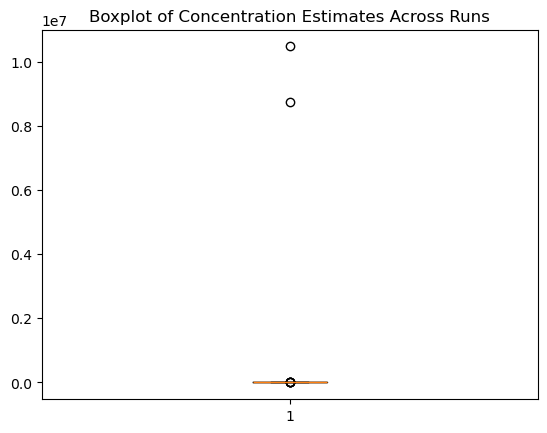

In [81]:
plt.boxplot(concs)
plt.title("Boxplot of Concentration Estimates Across Runs")



In [83]:
p5 , p95 = np.percentile(concs, [5, 95])
filtered_concs = concs[(concs >= p5) & (concs <= p95)]

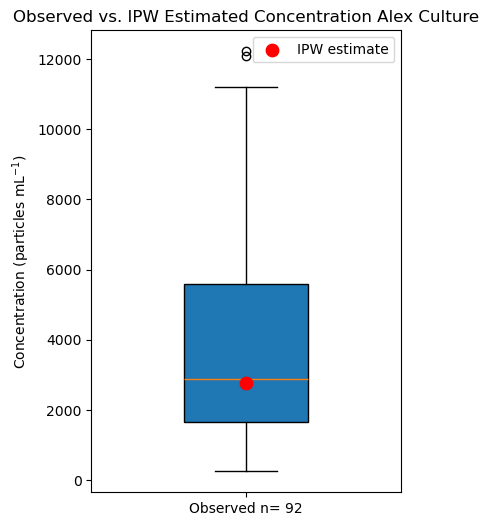

In [84]:
fig, ax = plt.subplots(figsize=(4, 6))

# Boxplot of observed concentrations
ax.boxplot(
    filtered_concs,
    widths=0.4,
    patch_artist=True
)

# Overlay estimated true concentration
ax.scatter(
    1,
    conc_underlying,
    color="red",
    s=80,
    zorder=3,
    label="IPW estimate"
)

ax.set_xticks([1])
ax.set_xticklabels([f"Observed n= {n_conc_files}"])
ax.set_ylabel("Concentration (particles mL$^{-1}$)")
ax.legend()
plt.title("Observed vs. IPW Estimated Concentration Alex Culture")
plt.show()